In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
experiment_name = '2026-03-12_BRaf-cterm-activity'
library = 'BRAF_cterm_activity'
data_storage_path = '/Users/oliviaweissenfels/desktop/Sequencing/analysis/activity_cterm/condition-comparison-scores_heatmaps/'
sjf0628_df = pd.read_csv('/Users/oliviaweissenfels/Desktop/Sequencing/analysis/activity_cterm/SJF0628_BRAF-cterm_activity/2026-03-12_BRaf-cterm-activity_SJF0628_Replicate_scores.tsv', sep='\t')
sjf0661_df = pd.read_csv('/Users/oliviaweissenfels/Desktop/Sequencing/analysis/activity_cterm/SJF0661_BRAF-cterm_activity/2026-03-12_BRaf-cterm-activity_SJF0661_Replicate_scores.tsv', sep='\t')
dmso_df = pd.read_csv('/Users/oliviaweissenfels/Desktop/Sequencing/analysis/activity_cterm/DMSO_BRAF-cterm_activity/2026-03-12_BRaf-cterm-activity_DMSO_Replicate_scores.tsv', sep='\t')

# Merge the dataframes
# Merge DMSO and SJF0628
merged_step1 = pd.merge(dmso_df[['variant', 'standard-adjusted score']], 
                        sjf0628_df[['variant', 'standard-adjusted score']], 
                        on='variant', 
                        how='inner', 
                        suffixes=('_DMSO', '_SJF0628'))

# Merge the result with SJF0661
merged_scores = pd.merge(merged_step1, 
                         sjf0661_df[['variant', 'standard-adjusted score']], 
                         on='variant', 
                         how='inner')

# Rename the final column so it matches the others
merged_scores = merged_scores.rename(columns={'standard-adjusted score': 'standard-adjusted score_SJF0661'})

# Calculate scores
merged_scores['SJF0628-DMSO Score Difference'] = merged_scores['standard-adjusted score_SJF0628'] - merged_scores['standard-adjusted score_DMSO']
merged_scores['SJF0628-DMSO Score Percent'] = merged_scores['SJF0628-DMSO Score Difference'] / merged_scores['standard-adjusted score_DMSO']
merged_scores['SJF0628-SJF0661 Score Difference'] = merged_scores['standard-adjusted score_SJF0628'] - merged_scores['standard-adjusted score_SJF0661']
merged_scores['SJF0628-SJF0661 Score Percent'] = merged_scores['SJF0628-SJF0661 Score Difference'] / merged_scores['standard-adjusted score_SJF0661']
merged_scores['SJF0661-DMSO Score Difference'] = merged_scores['standard-adjusted score_SJF0661'] - merged_scores['standard-adjusted score_DMSO']
merged_scores['SJF0661-DMSO Score Percent'] = merged_scores['SJF0661-DMSO Score Difference'] / merged_scores['standard-adjusted score_DMSO']

# View the top of the aligned data
print(merged_scores.head())

# Save to path
save_path = '/Users/oliviaweissenfels/Desktop/Sequencing/analysis/activity_cterm/condition-comparison-scores_heatmaps/Aligned-Condition-Scores_cterm-activity.csv'
merged_scores.to_csv(save_path, index=False)

  variant  standard-adjusted score_DMSO  standard-adjusted score_SJF0628  \
0   A115-                      0.647239                         0.386318   
1   A115A                      0.845204                         0.392591   
2   A115C                      0.557701                         0.362999   
3   A115D                      0.873386                         0.343407   
4   A115E                      0.564600                         0.326871   

   standard-adjusted score_SJF0661  SJF0628-DMSO Score Difference  \
0                         0.733787                      -0.260922   
1                         0.742743                      -0.452613   
2                         0.588315                      -0.194701   
3                         0.720993                      -0.529980   
4                         0.633471                      -0.237729   

   SJF0628-DMSO Score Percent  SJF0628-SJF0661 Score Difference  \
0                   -0.403130                         -0.3474

In [15]:
def convert_AA_abbreviation(heatmap_data):
    for i, row in heatmap_data.iterrows():
        if row['Mutation'] == 'Arg':
            heatmap_data.at[i, 'Mutation'] = 'R'
        elif row['Mutation'] == 'His':
            heatmap_data.at[i, 'Mutation'] = 'H'
        elif row['Mutation'] == 'Lys':
            heatmap_data.at[i, 'Mutation'] = 'K'
        elif row['Mutation'] == 'Asp':
            heatmap_data.at[i, 'Mutation'] = 'D'
        elif row['Mutation'] == 'Glu':
            heatmap_data.at[i, 'Mutation'] = 'E'
        elif row['Mutation'] == 'Ser':
            heatmap_data.at[i, 'Mutation'] = 'S'
        elif row['Mutation'] == 'Thr':
            heatmap_data.at[i, 'Mutation'] = 'T'
        elif row['Mutation'] == 'Asn':
            heatmap_data.at[i, 'Mutation'] = 'N'
        elif row['Mutation'] == 'Gln':
            heatmap_data.at[i, 'Mutation'] = 'Q'
        elif row['Mutation'] == 'Cys':
            heatmap_data.at[i, 'Mutation'] = 'C'
        elif row['Mutation'] == 'Gly':
            heatmap_data.at[i, 'Mutation'] = 'G'
        elif row['Mutation'] == 'Pro':
            heatmap_data.at[i, 'Mutation'] = 'P'
        elif row['Mutation'] == 'Ala':
            heatmap_data.at[i, 'Mutation'] = 'A'
        elif row['Mutation'] == 'Val':
            heatmap_data.at[i, 'Mutation'] = 'V'
        elif row['Mutation'] == 'Ile':
            heatmap_data.at[i, 'Mutation'] = 'I'
        elif row['Mutation'] == 'Leu':
            heatmap_data.at[i, 'Mutation'] = 'L'
        elif row['Mutation'] == 'Met':
            heatmap_data.at[i, 'Mutation'] = 'M'
        elif row['Mutation'] == 'Phe':
            heatmap_data.at[i, 'Mutation'] = 'F'
        elif row['Mutation'] == 'Tyr':
            heatmap_data.at[i, 'Mutation'] = 'Y'
        elif row['Mutation'] == 'Trp':
            heatmap_data.at[i, 'Mutation'] = 'W'
        elif row['Mutation'] == 'Ter':
            heatmap_data.at[i, 'Mutation'] = '*'
    return heatmap_data

In [16]:
def heatmap_from_ReplicateScores(metric, minimum, maximum, center, title, scale, firstPosition, lastPosition):
    sns.set(font_scale=1.6)

    #Change mutation to single letter abbreviations
    heatmap_data = Replicate_scores.copy()
    heatmap_data = convert_AA_abbreviation(heatmap_data)
    
    #Remove standards and position 1, neither of which have scores
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'standard') 
                                #& (heatmap_data['Position'] != 1)
                               ]
    # Convert Position column to numeric, setting errors='coerce' to turn non-numeric values into NaN
    heatmap_data['Position'] = pd.to_numeric(heatmap_data['Position'], errors='coerce')

    # Drop rows where Position is NaN (due to non-numeric values) before converting to int
    heatmap_data = heatmap_data.dropna(subset=['Position'])

    # Now safely convert Position to integer type
    heatmap_data['Position'] = heatmap_data['Position'].astype(int)
    
    heatmap_data = heatmap_data[heatmap_data['Position'] > (firstPosition-1)]
    heatmap_data = heatmap_data[heatmap_data['Position'] < (lastPosition+1)]
    
    #remove wild type data
    heatmap_data = heatmap_data[(heatmap_data['Mutation'] != 'synonymous') & (heatmap_data['Mutation'] != 'wild type') & (heatmap_data['Mutation'] != 'unknown')]
    
    if scale == 'log2':
        #calculate log2 score
        heatmap_data['log2_score'] = np.log2(heatmap_data[metric])
    
        #restructure it to be in the correct form for a heatmap. Each value is the average ratio for that mutation
        #at that position
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])['log2_score'].mean().unstack()
    elif scale == 'linear':
        heatmap_data= heatmap_data.groupby(['Position', 'Mutation'])[metric].mean().unstack()

    #transpose data so ORF position is on the x-axis
    heatmap_data= heatmap_data.transpose()

    orders = ['R' ,'K', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'C', 'G', 'P', 'A', 'V', 'I', 'L', 'M', 'F', 'Y', 'W', '*', '-']

    plt.figure(figsize = (80,10))

    # Reindex data
    reindexed_data = heatmap_data.reindex(orders, axis=0)

    # Plot data with colormap
    cmap_data = plt.cm.RdBu_r

    ax = sns.heatmap(reindexed_data, cmap=cmap_data, 
                     vmin=minimum, vmax=maximum, 
                     center=center)

    plt.title(title, fontsize = 30)
    plt.xlabel('Position', fontsize = 40, fontname='Sans Serif')
    plt.ylabel('Mutation', fontsize = 40, fontname='Sans Serif')
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)

    plt.title(title, fontsize = 40)

    # Make tick labels bold
    for label in plt.gca().get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    for label in plt.gca().get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontname('Sans Serif')

    plt.tick_params(left=False, bottom=True) ## other options are right and top

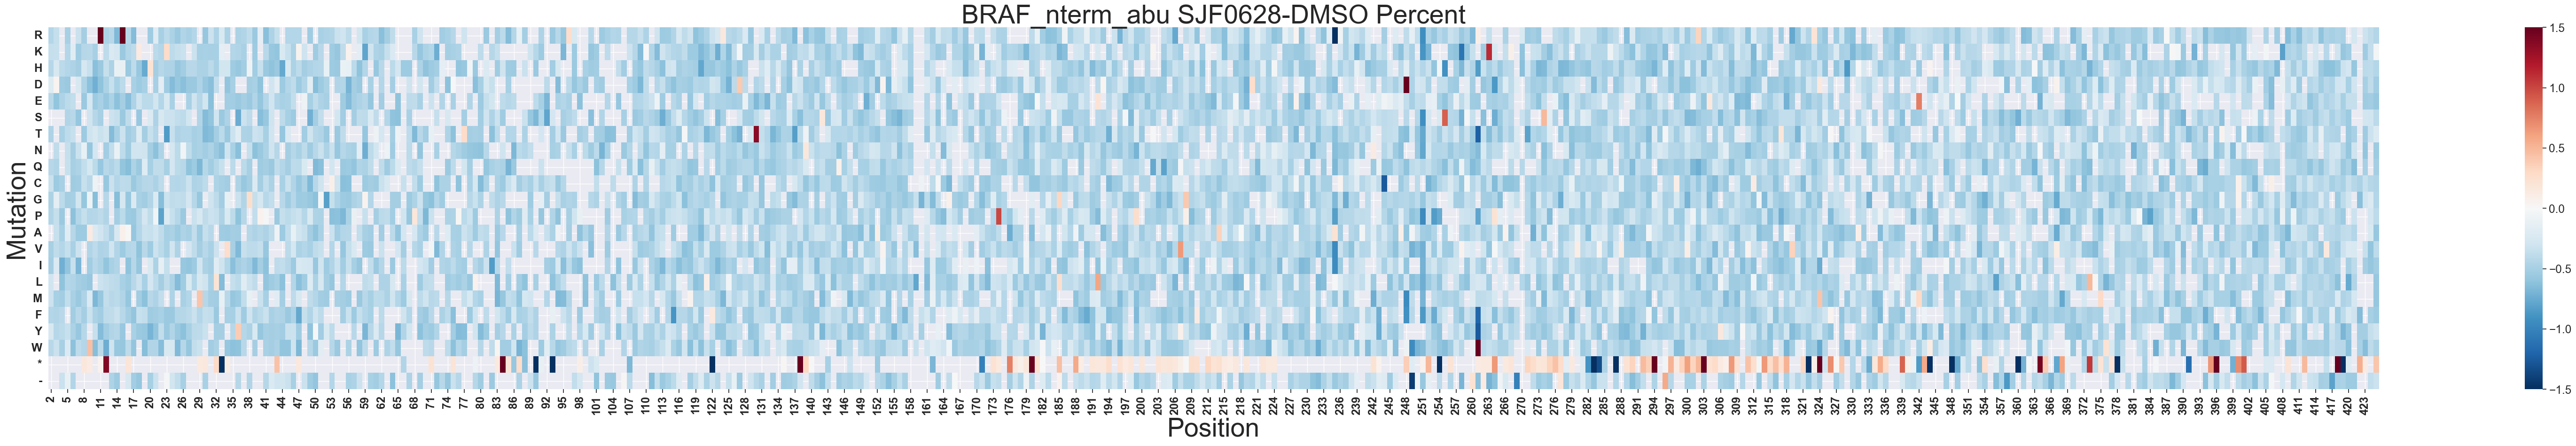

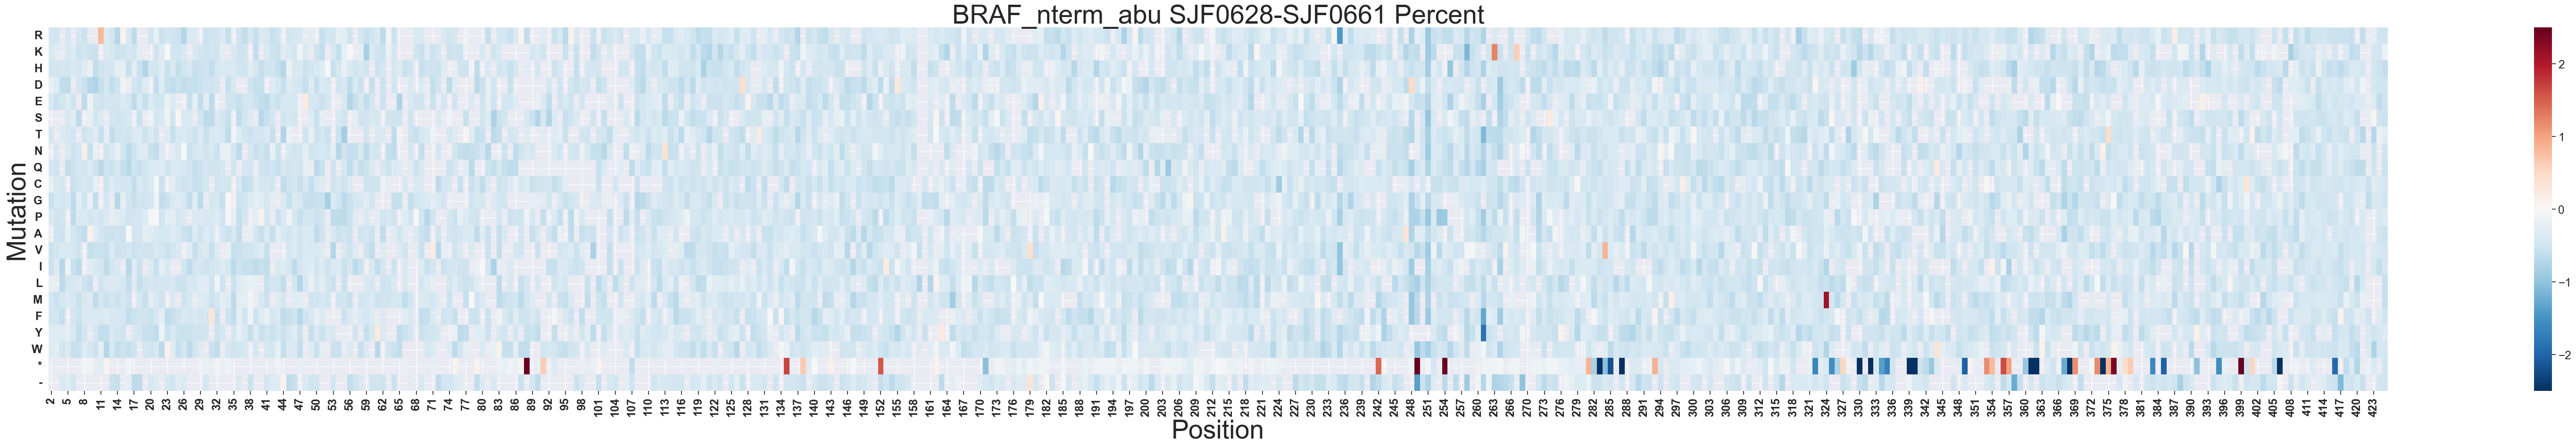

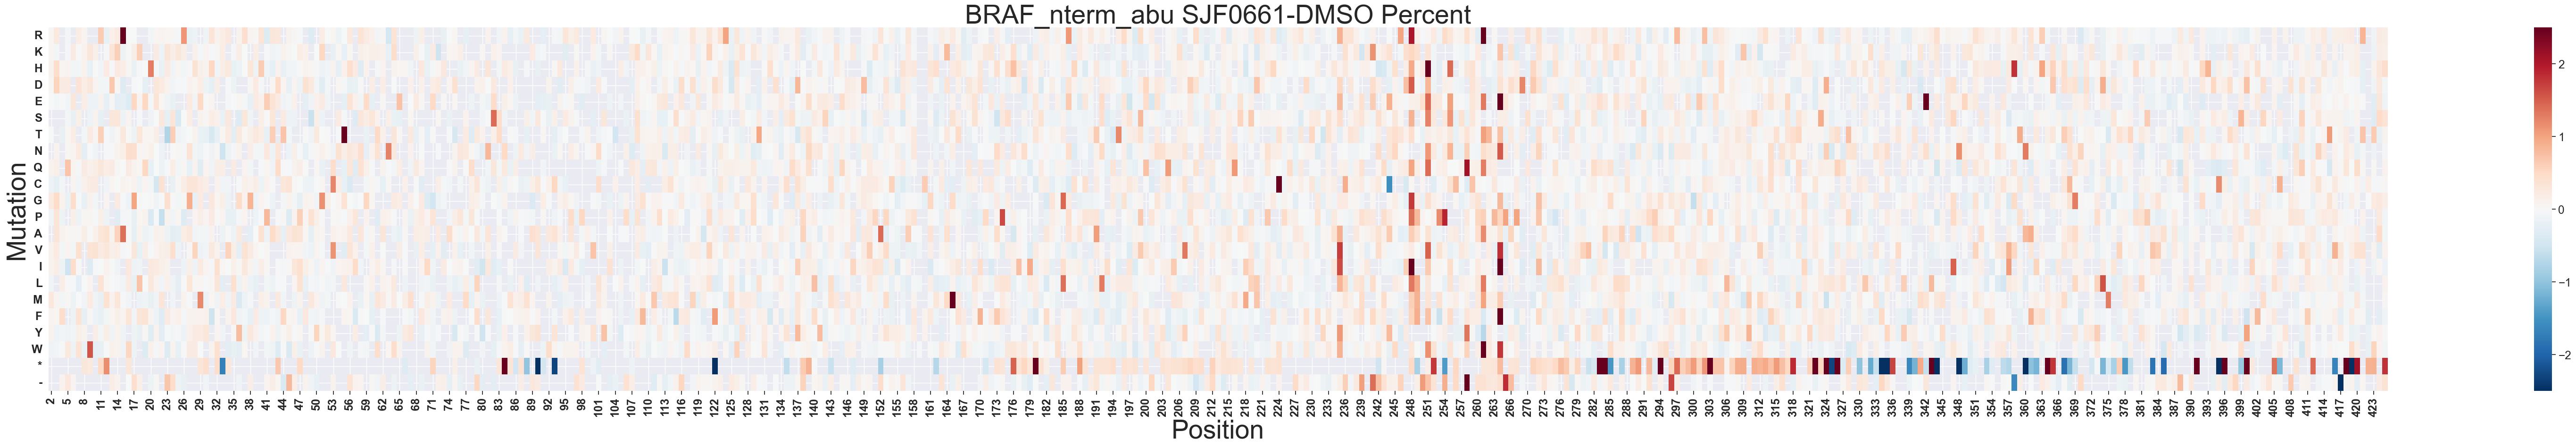

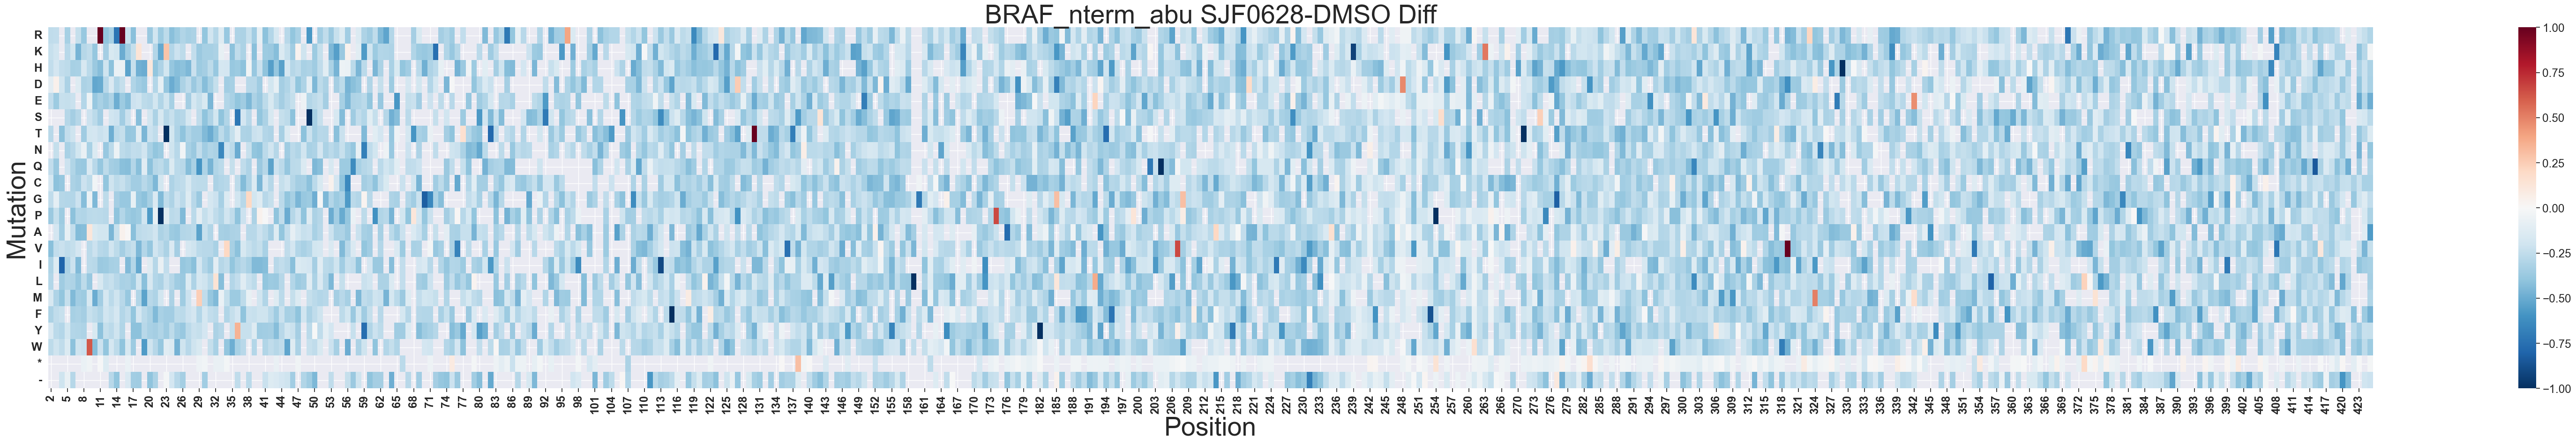

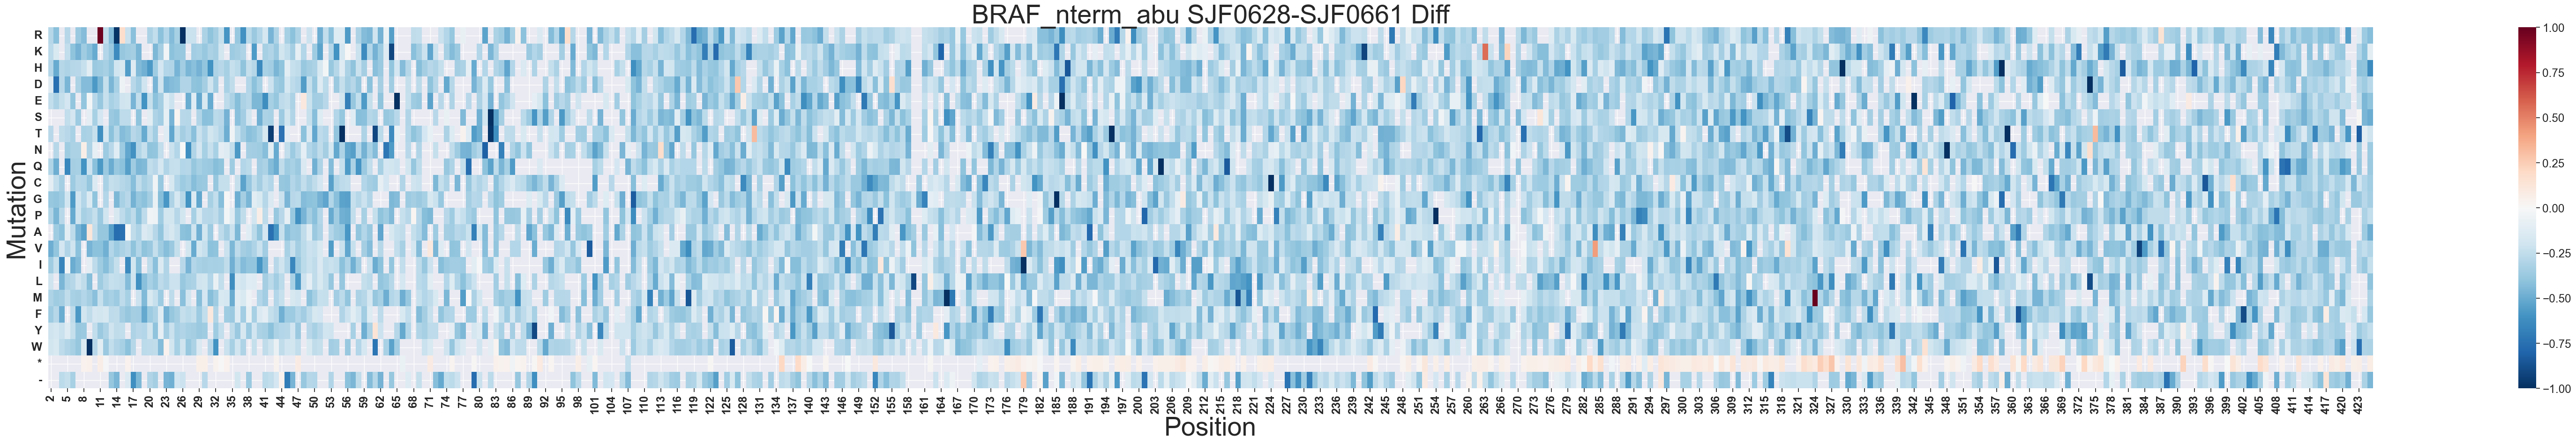

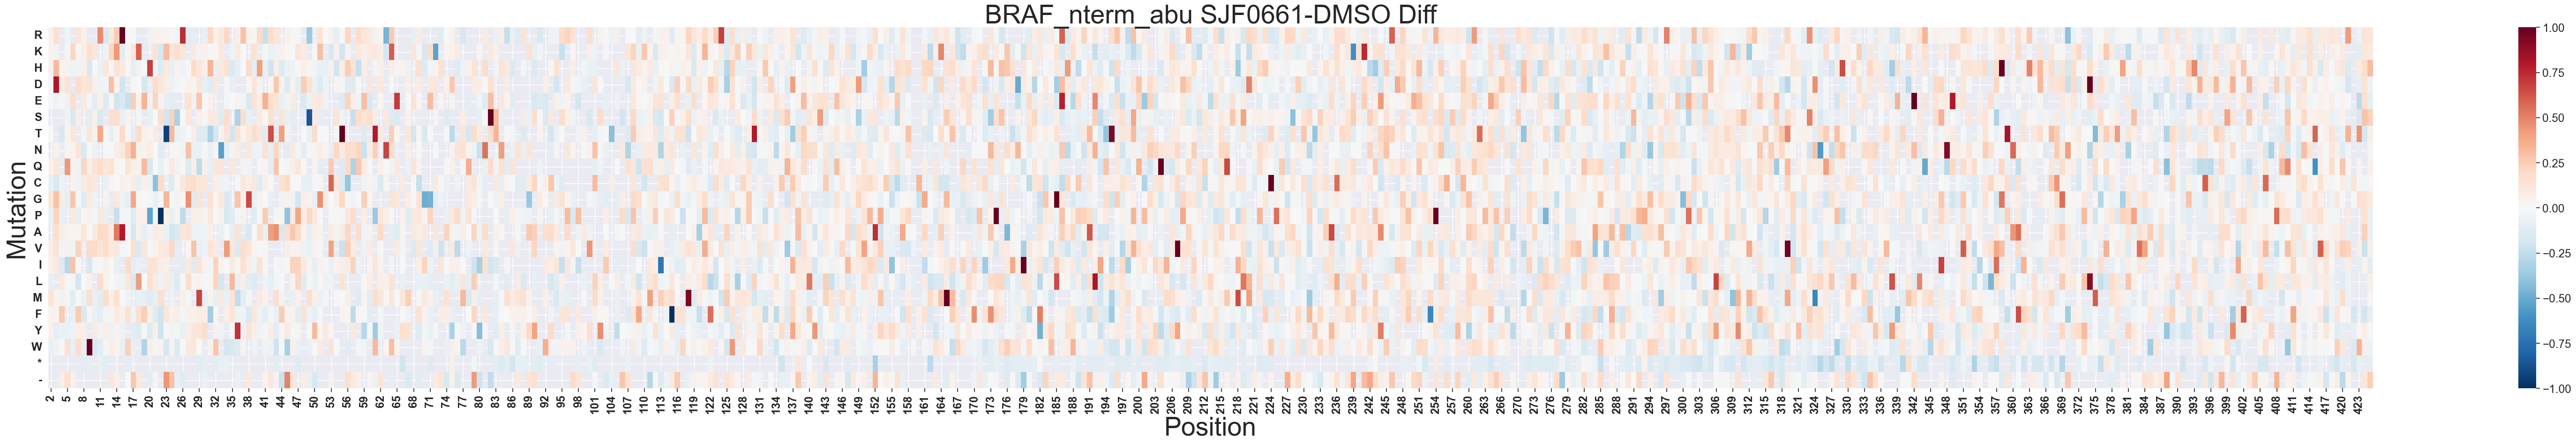

In [17]:
# Bring 'Position' and 'Mutation' back into your dataset from the DMSO file
merged_scores = pd.merge(merged_scores, dmso_df[['variant', 'Position', 'Mutation', 'Wild Type Residue']], on='variant', how='left')

# point 'Replicate_scores' to your new merged dataframe
Replicate_scores = merged_scores.copy()

# 3. calculate max_position using the 'Position' column (NOT 'variant')
Replicate_scores['Position'] = pd.to_numeric(Replicate_scores['Position'], errors='coerce')
max_position = int(Replicate_scores['Position'].max())

# Plot 1: SJF0628 vs DMSO (Percent)
heatmap_from_ReplicateScores('SJF0628-DMSO Score Percent', -1.5, 1.5, 0, library + ' SJF0628-DMSO Percent', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0628_DMSO_Percent.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0628_DMSO_Percent.png')

# Plot 2: SJF0628 vs SJF0661 (Percent)
heatmap_from_ReplicateScores('SJF0628-SJF0661 Score Percent', -2.5, 2.5, 0, library + ' SJF0628-SJF0661 Percent', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0628_SJF0661_Percent.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0628_SJF0661_Percent.png')

# Plot 3: SJF0661 vs DMSO (Percent)
heatmap_from_ReplicateScores('SJF0661-DMSO Score Percent', -2.5, 2.5, 0, library + ' SJF0661-DMSO Percent', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0661_DMSO_Percent.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0661_DMSO_Percent.png')

# Plot 4: SJF0628 vs DMSO (Difference)
heatmap_from_ReplicateScores('SJF0628-DMSO Score Difference', -1, 1, 0, library + ' SJF0628-DMSO Diff', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0628_DMSO_Diff.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0628_DMSO_Diff.png')

# Plot 5: SJF0628 vs SJF0661 (Difference)
heatmap_from_ReplicateScores('SJF0628-SJF0661 Score Difference', -1, 1, 0, library + ' SJF0628-SJF0661 Diff', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0628_SJF0661_Diff.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0628_SJF0661_Diff.png')

# Plot 6: SJF0661 vs DMSO (Difference)
heatmap_from_ReplicateScores('SJF0661-DMSO Score Difference', -1, 1, 0, library + ' SJF0661-DMSO Diff', 'linear', 1, max_position)
plt.savefig(data_storage_path + experiment_name + '_SJF0661_DMSO_Diff.svg')
plt.savefig(data_storage_path + experiment_name + '_SJF0661_DMSO_Diff.png')